# MNIST autoencoder
A simple example of a convolutional autoencoder, based on some existing tutorials.

Source Material
- [Toni Esteves - Kaggle](https://www.kaggle.com/code/toniesteves/pytorch-convolutional-autoencoder)
- [Javier Canales Luna - Data Camp](https://www.datacamp.com/tutorial/pytorch-cnn-tutorial)
- 

In [1]:
import numpy as np


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
import torch
from torchvision import datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F

### Load the data

In [4]:
# convert data to torch.FloatTensor
transform = transforms.ToTensor()


In [5]:
# load the training and test datasets
train_data = datasets.MNIST(root      = 'data', 
                            train     = True,
                            download  = True, 
                            transform = transform)

test_data = datasets.MNIST(root      = 'data', 
                           train     = False,
                           download  = True, 
                           transform = transform)

100.0%
100.0%
100.0%
100.0%


In [6]:
# Create training and test dataloaders

num_workers = 0

# how many samples per batch to load
batch_size = 20


In [7]:

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, num_workers=num_workers)

### Visualise the data

In [9]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

img = np.squeeze(images[1])


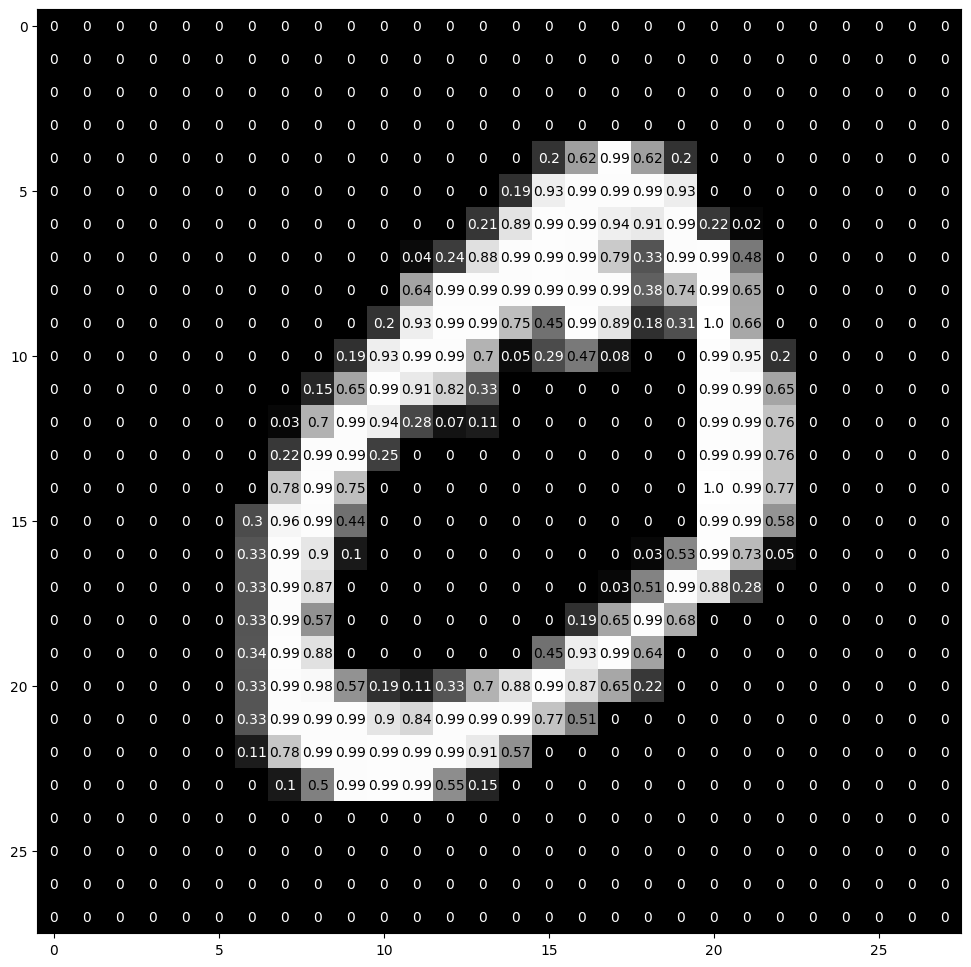

In [10]:
dataiterfig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
ax.imshow(img, cmap='gray')
width, height = img.shape
thresh = img.max()/2.5
for x in range(width):
    for y in range(height):
        val = round(img[x][y],2) if img[x][y] !=0 else 0
        ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center',
                    color='white' if img[x][y]<thresh else 'black')


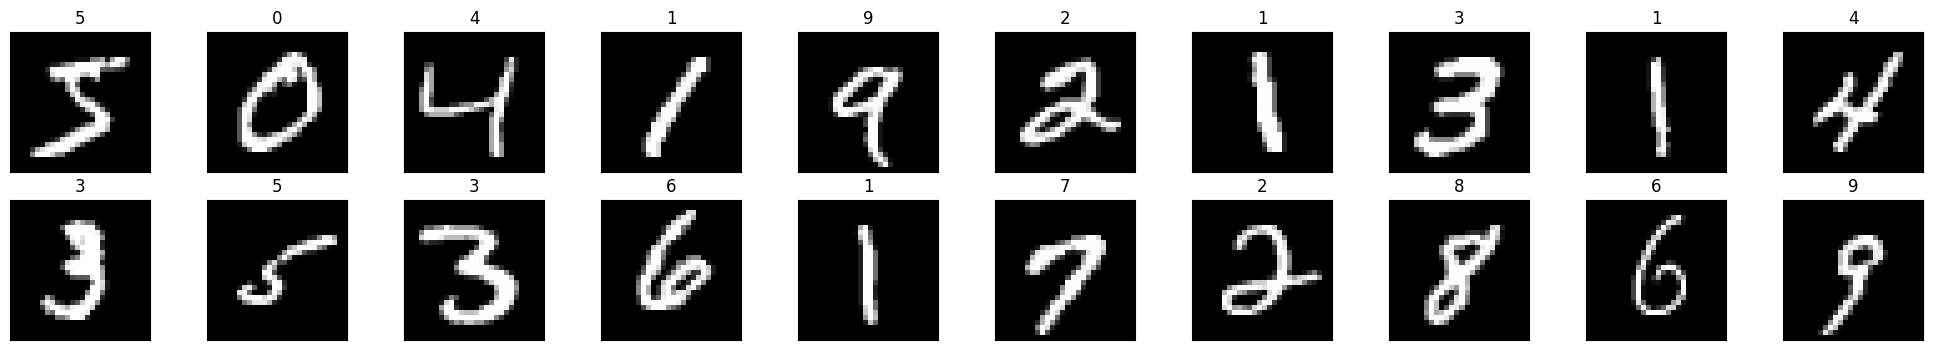

In [13]:
# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

### Define the NN architecture

In [14]:
# define the NN architecture
class ConvAutoencoder(nn.Module):
    
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        
        ## encoder layers ##
        # conv layer (depth from 1 --> 16), 3x3 kernels
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)  
        # conv layer (depth from 16 --> 4), 3x3 kernels
        self.conv2 = nn.Conv2d(16, 4, 3, padding=1)
        # pooling layer to reduce x-y dims by two; kernel and stride of 2
        self.pool = nn.MaxPool2d(2, 2)
        
        ## decoder layers ##
        ## a kernel of 2 and a stride of 2 will increase the spatial dims by 2
        self.t_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.t_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)


    def forward(self, x):
        ## encode ##
        # add hidden layers with relu activation function
        # and maxpooling after
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # add second hidden layer
        x = F.relu(self.conv2(x))
        x = self.pool(x)  # compressed representation
        
        ## decode ##
        # add transpose conv layers, with relu activation function
        x = F.relu(self.t_conv1(x))
        # output layer (with sigmoid for scaling from 0 to 1)
        x = torch.sigmoid(self.t_conv2(x))
                
        return x

### Set up the training run

initialize the NN

In [15]:
model = ConvAutoencoder()
print(model)

ConvAutoencoder(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (t_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (t_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
)


specify loss function

In [18]:
images.shape

(20, 1, 28, 28)

In [20]:
help(criterion)

Help on MSELoss in module torch.nn.modules.loss object:

class MSELoss(_Loss)
 |  MSELoss(size_average=None, reduce=None, reduction: str = 'mean') -> None
 |
 |  Creates a criterion that measures the mean squared error (squared L2 norm) between
 |  each element in the input :math:`x` and target :math:`y`.
 |
 |  The unreduced (i.e. with :attr:`reduction` set to ``'none'``) loss can be described as:
 |
 |  .. math::
 |      \ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad
 |      l_n = \left( x_n - y_n \right)^2,
 |
 |  where :math:`N` is the batch size. If :attr:`reduction` is not ``'none'``
 |  (default ``'mean'``), then:
 |
 |  .. math::
 |      \ell(x, y) =
 |      \begin{cases}
 |          \operatorname{mean}(L), &  \text{if reduction} = \text{`mean';}\\
 |          \operatorname{sum}(L),  &  \text{if reduction} = \text{`sum'.}
 |      \end{cases}
 |
 |  :math:`x` and :math:`y` are tensors of arbitrary shapes with a total
 |  of :math:`N` elements each.
 |
 |  The mean operation stil

In [21]:
criterion = nn.MSELoss()

In [22]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### run training loop

In [23]:
# number of epochs to train the model
n_epochs = 30


In [24]:
for epoch in range(1, n_epochs+1):
    # monitor training loss
    train_loss = 0.0
    
    ###################
    # train the model #
    ###################
    for data in train_loader:
        # _ stands in for labels, here
        # no need to flatten images
        images, _ = data
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)
        # calculate the loss
        loss = criterion(outputs, images)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update running training loss
        train_loss += loss.item()*images.size(0)
            
    # print avg training statistics 
    train_loss = train_loss/len(train_loader)
    print(f'Epoch: {epoch} \tTraining Loss: {train_loss:.6f}')

Epoch: 1 	Training Loss: 0.419572
Epoch: 2 	Training Loss: 0.218616
Epoch: 3 	Training Loss: 0.203481
Epoch: 4 	Training Loss: 0.192732
Epoch: 5 	Training Loss: 0.186010
Epoch: 6 	Training Loss: 0.181724
Epoch: 7 	Training Loss: 0.178617
Epoch: 8 	Training Loss: 0.175899
Epoch: 9 	Training Loss: 0.173466
Epoch: 10 	Training Loss: 0.171835
Epoch: 11 	Training Loss: 0.170616
Epoch: 12 	Training Loss: 0.169605
Epoch: 13 	Training Loss: 0.168786
Epoch: 14 	Training Loss: 0.167987
Epoch: 15 	Training Loss: 0.167117
Epoch: 16 	Training Loss: 0.166259
Epoch: 17 	Training Loss: 0.165304
Epoch: 18 	Training Loss: 0.164408
Epoch: 19 	Training Loss: 0.163674
Epoch: 20 	Training Loss: 0.163101
Epoch: 21 	Training Loss: 0.162663
Epoch: 22 	Training Loss: 0.162270
Epoch: 23 	Training Loss: 0.161931
Epoch: 24 	Training Loss: 0.161660
Epoch: 25 	Training Loss: 0.161400
Epoch: 26 	Training Loss: 0.161170
Epoch: 27 	Training Loss: 0.160963
Epoch: 28 	Training Loss: 0.160765
Epoch: 29 	Training Loss: 0.1

### Evaluate results~

In [26]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)


In [27]:
# get sample outputs
output = model(images)


In [28]:
# prep images for display
images = images.numpy()
# output is resized into a batch of iages
output = output.view(batch_size, 1, 28, 28)
# use detach when it's an output that requires_grad
output = output.detach().numpy()


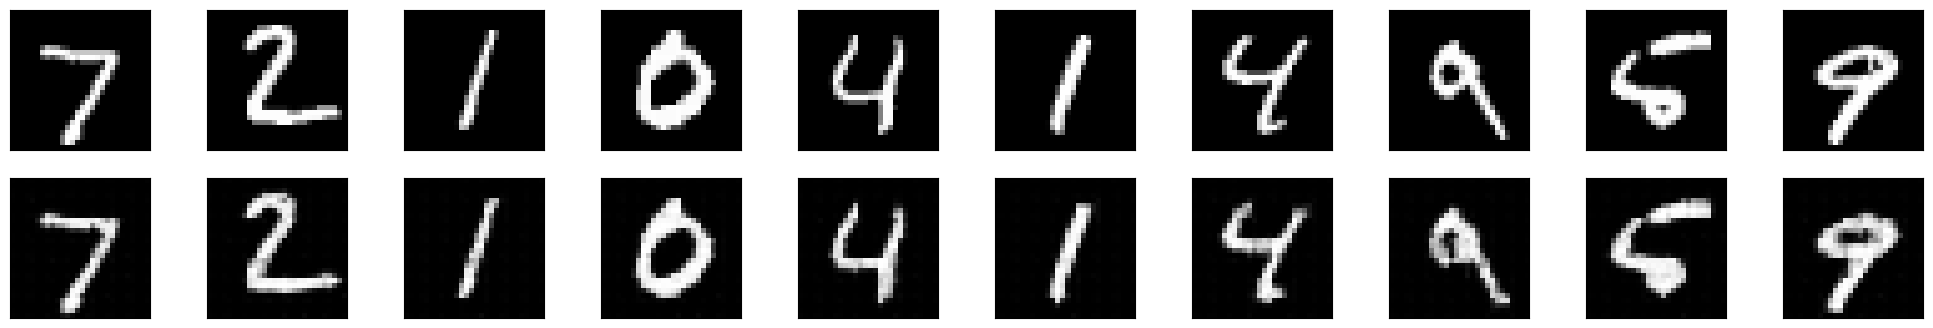

In [29]:
# plot the first ten input images and then reconstructed images
fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(25,4))

# input images on top row, reconstructions on bottom
for images, row in zip([images, output], axes):
    for img, ax in zip(images, row):
        ax.imshow(np.squeeze(img), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

